**ITESO - Instituto Tecnológico y de Estudios Superiores de Occidente**

---

Alejandro Fernández Vázquez

Andrea Lizeth Arevalo Solis

Arantxa Angulo Flores

# <span style="color:red">Boston Housing Projects - Random Forest Regressor</span>

Modelo de aprendizaje supervisado basado en ensamble de árboles de decisión
para predecir el precio de las viviendas (MEDV).

**Entrada:** `data/processed/housing_scaled.csv`

### <span style="color:orange">Bibliotecas</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

### <span style="color:orange">Carga de datos y parámetros</span> 

In [2]:
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

df = pd.read_csv('../data/processed/housing_scaled.csv')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 506, Columnas: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.670290,0.918420,-1.287909,0,-0.144217,0.475982,-0.120013,0.148015,-0.982843,-0.666608,-1.477181,0.786988,-1.088749,24.0
1,-0.663949,-0.579471,-0.593381,0,-0.740262,0.231390,0.367166,0.572202,-0.867883,-0.987329,-0.309941,0.786988,-0.495302,21.6
2,-0.663955,-0.579471,-0.593381,0,-0.740262,1.444822,-0.265812,0.572202,-0.867883,-0.987329,-0.309941,0.573183,-1.224272,34.7
3,-0.662420,-0.579471,-1.306878,0,-0.835284,1.147817,-0.809889,1.101820,-0.752922,-1.106115,0.110265,0.667741,-1.379766,33.4
4,-0.651339,-0.579471,-1.306878,0,-0.835284,1.384468,-0.511180,1.101820,-0.752922,-1.106115,0.110265,0.786988,-1.038819,36.2


### <span style="color:orange">Set de entrenamiento y set de validación</span> 

80 % - Train

20 % - Test

In [3]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=params['modeling']['test_size'],
    random_state=params['modeling']['random_state']
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 404 filas
Test:  102 filas


### <span style="color:orange">Entrenamiento de modelo</span> 

In [4]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=params['modeling']['random_state']
)

rf.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


### <span style="color:orange">Evaluación de modelo</span>

In [5]:
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 2.9175
MAE:  2.0635
R²:   0.8839


### <span style="color:orange">Gráfica predicciones vs valores reales</span>

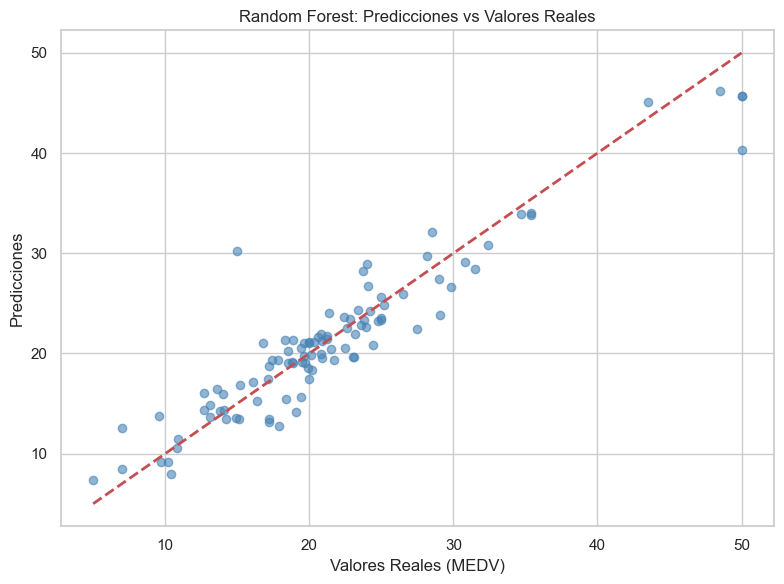

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Predicciones')
plt.title('Random Forest: Predicciones vs Valores Reales')
plt.tight_layout()
plt.show()

### <span style="color:orange">Importancia de variables</span>

La importancia de variables nos dice cuánto contribuye cada variable a las predicciones del modelo.
Random Forest calcula esto midiendo cuánto mejora la precisión cuando usa cada variable para dividir los árboles. Las variables más importantes son las que más reducen el error.

Nos sirve para:

* Confirmar si LSTAT y RM siguen siendo los predictores más fuertes (como vimos en la correlación del cuaderno 03)
* Validar que el modelo está aprendiendo patrones reales y no ruido
* Documentar qué variables pesan más en la predicción del precio

Ejecuta la celda y vemos qué variables le importan más al Random Forest.

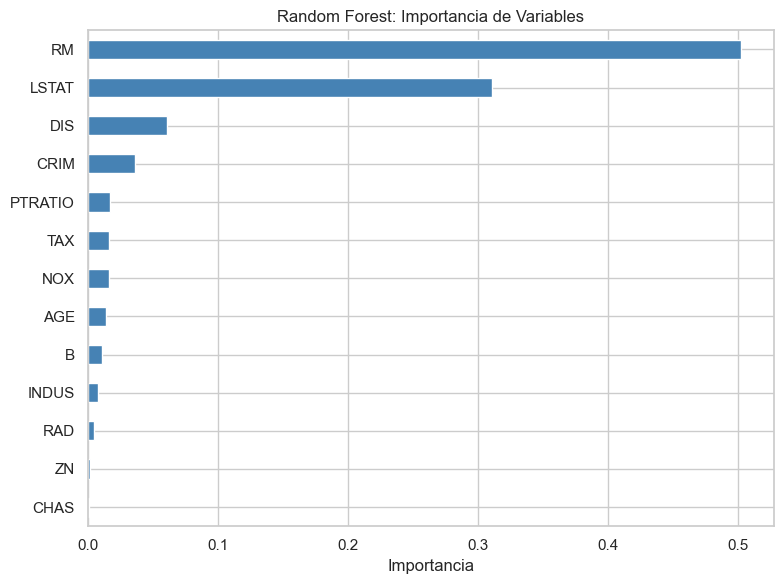

In [7]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='steelblue')
plt.title('Random Forest: Importancia de Variables')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## <span style="color:green">Conclusiones</span>

**Desempeño del modelo:**
Random Forest obtuvo un R² de 0.8839, explicando el 88% de la
variación en los precios de las viviendas. El RMSE de 2.92 indica
un error promedio de aproximadamente $2,917 por vivienda.

**Importancia de variables:**
RM y LSTAT concentran el 81% de la importancia del modelo,
confirmando el análisis de correlación del cuaderno 03.
Las demás variables tienen contribuciones marginales pero
complementarias para capturar patrones no lineales.

**Ventaja sobre Regresión Lineal:**
Random Forest captura relaciones no lineales entre variables,
lo que explica su mejor desempeño frente a modelos lineales
en este dataset.